# MNIST Classification using Multilayer Perceptron


One of your assignments is to implement a backpropagation algorithm on a **simple MLP architecture**. Now, based on that simple BPNN architecture, develop a new model of BPNN capable of tackling a general digit recognition task. Once again, please employ digit datasets taken from sklearn import datasets and split into training (80%) and validation (20%) datasets. Since the size of the sample image is 8 x 8 pixels, so the
architecture of your new BPNN model has to be adjusted accordingly. Your python notebook must include the computation of 

(A) **training accuracy and validation accuracy curves**, and 

(B) **performance analysis of the model based on the associated confusion matrix**

## Import Libraries

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import plot_confusion_matrix

## Import Dataset

In [4]:
from sklearn import datasets
digits = datasets.load_digits()

In [5]:
X = digits['images']
y = digits['target']
target_names = digits['target_names']

target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
print(f'Images (x) Shape : {X.shape}')
print(f'Target (y) Shape : {y.shape}')

Images (x) Shape : (1797, 8, 8)
Target (y) Shape : (1797,)


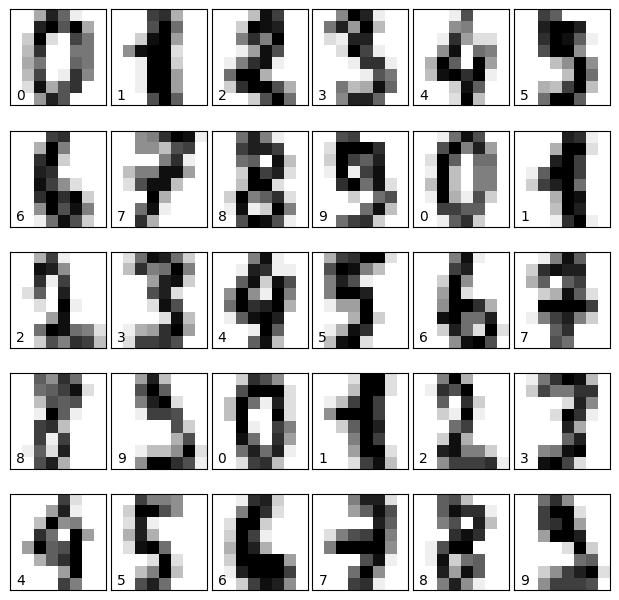

In [7]:
# Display sample data
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(30):
    ax = fig.add_subplot(5, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(X[i], cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 7, str(y[i]))

## Preprocess

In [8]:
n_samples = len(X)
X = X.reshape((n_samples, -1))
print(f"After reshape = {X.shape}")


After reshape = (1797, 64)


Split dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)
print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


## Train model

In [10]:
from sklearn.model_selection import ShuffleSplit
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

In [11]:
# clf = MLPClassifier(hidden_layer_sizes=(32, 16), activation = 'identity', solver='sgd', alpha=0.2, batch_size=32)
clf = MLPClassifier()
clf.fit(X_train, y_train)
print(f'Train Accuracy = {clf.score(X_train, y_train)}')
print(f'Test Accuracy = {clf.score(X_test, y_test)}')

Train Accuracy = 1.0
Test Accuracy = 0.9861111111111112


### Model Summary

In [10]:
print("Weights\n", clf.coefs_)

Weights
 [array([[-6.54489580e-06,  1.12197597e-24, -1.88995558e-25, ...,
         4.96222342e-07, -1.67221124e-23,  1.55255224e-21],
       [ 1.61261789e-01, -1.62446053e-01,  2.08776169e-01, ...,
        -5.91871108e-02, -3.35945752e-02, -1.02937447e-01],
       [ 7.64660268e-02,  1.56349580e-01,  8.47638569e-02, ...,
         1.19675820e-02,  2.38580111e-01,  3.62723126e-02],
       ...,
       [ 1.59143056e-01, -1.88880772e-01,  1.44765845e-01, ...,
         1.27968082e-01, -8.20046025e-02, -1.30530199e-01],
       [ 6.87252055e-02, -6.55987918e-02,  3.57220962e-02, ...,
         1.42724807e-01,  9.64230297e-02, -1.21510411e-01],
       [-1.52108650e-02, -4.73430275e-09,  9.88573824e-02, ...,
         5.71187876e-02,  2.49046967e-01,  7.58129293e-02]]), array([[-2.01006696e-01,  1.49851905e-01,  5.42856148e-02,
         2.02450632e-01, -2.61291996e-01,  3.23790253e-02,
        -2.65340864e-02,  9.84123341e-02,  1.57304074e-01,
         2.97722616e-02],
       [ 2.33317059e-02,  2.0

In [11]:
print("Total Iteration done : ", clf.n_iter_)
print("Number of layer : ", clf.n_layers_)
print("Number of output : ", clf.n_outputs_)

Total Iteration done :  134
Number of layer :  3
Number of output :  10


## A. Training accuracy and validation accuracy curves

#### Function to plot training & validation accuracy curves

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(8, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes,
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes.legend(loc="best")

    return plt

### Generate Training accuracy & Validation accuracy curves

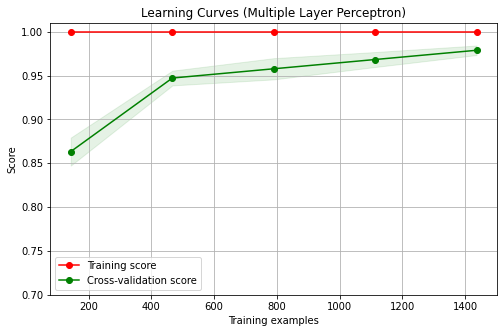

In [13]:
title = "Learning Curves (Multiple Layer Perceptron)"

# Cross validation with 5 iterations each time with 20% data 
# randomly selected as a validation set.
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

estimator = MLPClassifier()
plot_learning_curve(estimator, title, X, y, ylim=(0.7, 1.01),
                    cv=cv, n_jobs=-1)

plt.show()

## B. Performance analysis of the model based on the associated confusion matrix

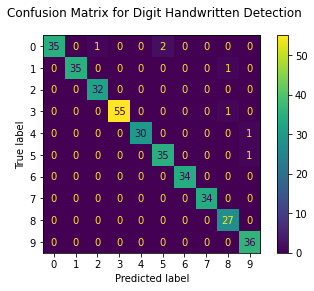

In [14]:
fig = plot_confusion_matrix(clf, X_test, y_test, labels=target_names)
fig.figure_.suptitle("Confusion Matrix for Digit Handwritten Detection")
plt.show()

#### Extra metrics : Loss Curve

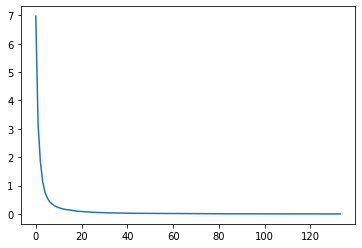

In [15]:
plt.plot(clf.loss_curve_)